In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st
import re
import os

In [2]:
def bins(flt1, flt2):
    if flt1 == 0 and flt2 >= 2:
        return ("loss_retarget")
    if flt1 == 0 and flt2 == 1:
        return ("loss_noretarget")
    if flt1 >= 1 and flt2 == 1:
        return("present_noretarget")
    if flt1 >= 1 and flt2 >= 2:
        return("present_retarget")
    if flt1 >= 1 and flt2 == 0:
        return("present_unknowntargeting")
    if flt1 ==0  and flt2 == 0:
        return("loss_unknowntargeting")
    else:
        print("input is not float between 0 and inf")      

def binscol(df):
    output= pd.DataFrame(columns=species)
    for spp in species:
        predictions=[]
        column1 = "".join([spp," Presence/Absence"])
        column2 = "".join([spp," Retargeting"])
        for i in range(0,len(df)):
            flt1 = df[column1][i]
            flt2 = df[column2][i]
            prediction = bins(flt1,flt2)
            predictions.append(prediction)
        output[spp] = predictions
        #output['description'] = df.index
        output = output.set_index(df.index)
    return(output)

def fisher(df,factor,cols):
    dfcounts=df.loc[:,cols].groupby(factor).sum()
    oddsratio, pvalue = st.fisher_exact([[dfcounts.iloc[0,0], dfcounts.iloc[0,1]],[dfcounts.iloc[1,0],dfcounts.iloc[1,1]]])
    print(dfcounts,"\n","The Fisher's pvalue is", pvalue)


In [3]:
#import absence-presence matrix
APmat = pd.read_csv("20240805_aaRS_processing_collapsemodels.csv", index_col=["targeting", "description"]).rename(columns ={
    'Arabidopsis thaliana' : 'A. thaliana',
    'Balanophera fungosa' : 'B. fungosa',
    "Phalaenopsis equestris":'P. equestris' ,
    "Epipogium aphyllum":'E. aphyllum',
    "Epipogium roseum":'E. roseum',	
    "Manihot esculenta":"M. esculenta",	
    "Rafflesia cantleyi": "R. cantleyi",
    "Sapria himalayana" :'S. himalayana',	
    "Santalum album":'S. album',
    "Rhopalocnemis phalloides":'R. phalloides',
    "Balanophora fungosa":'B. fungosa',
    "Rhododendron williamsianum":'R. williamsianum',	
    'Monotropa hypopitys':'M. hypopitys'})
APmat.columns


Index(['A. thaliana', 'Amborella trichopoda', 'B. fungosa',
       'Cuscuta australis', 'Cuscuta campestris', 'Dendropemon caribaeus',
       'E. aphyllum', 'E. roseum', 'M. hypopitys', 'Ipomoea trifida',
       'M. esculenta', 'Mimulus guttatus', 'Malania oleifera', 'Oryza sativa',
       'P. equestris', 'Phtheirospermum japonicum', 'R. cantleyi',
       'R. phalloides', 'R. williamsianum', 'S. album', 'Striga asiatica',
       'S. himalayana', 'Spirodela polyrhiza', 'Viscum album',
       'Vitis vinifera'],
      dtype='object')

In [4]:
#import predicted retargeting matrix for mito and chloro
MTmat = pd.read_csv("20240819_retargetingmatrix_mito.csv",index_col=["targeting","description"])

#just select the cytosolic aaRS
MTmat=MTmat.loc["cytosolic",:]
MTmat.head(20)

,P. equestris,E. aphyllum,E. roseum,M. esculenta,R. cantleyi,S. himalayana,S. album,R. phalloides,B. fungosa,R. williamsianum,M. hypopitys
description,,,,,,,,,,,
AlaRS,1.0,1.0,1.0,3.0,1.0,3.0,3.0,1.0,1.0,1.0,3.0
AsnRS,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
AspRS,1.0,1.0,1.0,1.0,1.0,3.0,1.0,1.0,3.0,0.0,1.0
CysRS,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
GlnRS,1.0,1.0,1.0,1.0,0.0,2.0,1.0,1.0,1.0,1.0,1.0
GluRS,1.0,1.0,1.0,1.0,0.0,2.0,1.0,0.0,0.0,1.0,0.0
GlyRS,2.0,3.0,1.0,3.0,1.0,3.0,1.0,1.0,1.0,1.0,0.0
HisRS,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0
IleRS,1.0,1.0,3.0,1.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0


In [5]:
CTmat = pd.read_csv("20240819_retargetingmatrix_chloro.csv",index_col=["targeting","description"])
#just select the cytosolic aaRS
CTmat=CTmat.loc["cytosolic",:]
CTmat.head(20)


,P. equestris,E. aphyllum,E. roseum,M. esculenta,R. cantleyi,S. himalayana,S. album,R. phalloides,B. fungosa,R. williamsianum,M. hypopitys
description,,,,,,,,,,,
AlaRS,3.0,3.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,3.0,1.0
AsnRS,1.0,1.0,1.0,1.0,0.0,1.0,1.0,2.0,1.0,1.0,1.0
AspRS,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,0.0,1.0
CysRS,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
GlnRS,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
GluRS,1.0,1.0,1.0,1.0,0.0,3.0,1.0,0.0,0.0,1.0,0.0
GlyRS,2.0,1.0,2.0,1.0,1.0,2.0,1.0,2.0,1.0,1.0,0.0
HisRS,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0
IleRS,1.0,1.0,1.0,1.0,3.0,1.0,1.0,1.0,2.0,1.0,1.0


In [6]:
#convert R cat and S him values to 0 except for GluRS
overwritespp = ['R. cantleyi','S. himalayana']
CTmat[overwritespp]=pd.concat([CTmat.loc[CTmat.index.get_level_values('description')!= 'GluRS',overwritespp].replace([1,2,3],0),
CTmat.loc[CTmat.index.get_level_values('description')== 'GluRS',overwritespp]])
CTmat

,P. equestris,E. aphyllum,E. roseum,M. esculenta,R. cantleyi,S. himalayana,S. album,R. phalloides,B. fungosa,R. williamsianum,M. hypopitys
description,,,,,,,,,,,
AlaRS,3.0,3.0,1.0,1.0,0.0,0.0,1.0,2.0,2.0,3.0,1.0
AsnRS,1.0,1.0,1.0,1.0,0.0,0.0,1.0,2.0,1.0,1.0,1.0
AspRS,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0
CysRS,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
GlnRS,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
GluRS,1.0,1.0,1.0,1.0,0.0,3.0,1.0,0.0,0.0,1.0,0.0
GlyRS,2.0,1.0,2.0,1.0,0.0,0.0,1.0,2.0,1.0,1.0,0.0
HisRS,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0
IleRS,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,2.0,1.0,1.0


In [7]:
MTmat= MTmat.drop(labels='PheRSB', axis=0).rename(index={'PheRSA':'PheRS'}) #drop PheRS b as we are only going to count as retargeted if both subunits are
CTmat= CTmat.drop(labels='PheRSB', axis=0).rename(index={'PheRSA':'PheRS'}) #drop PheRS b as we are only going to count as retargeted if both subunits are

In [8]:
species= list(MTmat.columns)
species

['P. equestris',
 'E. aphyllum',
 'E. roseum',
 'M. esculenta',
 'R. cantleyi',
 'S. himalayana',
 'S. album',
 'R. phalloides',
 'B. fungosa',
 'R. williamsianum',
 'M. hypopitys']

In [9]:
mito_chloro= pd.DataFrame(MTmat.index).set_index('description')
for spp in species:
    maxs=[]
    for i in MTmat.index:
        m = int(MTmat.at[i,spp])
        c = int(CTmat.at[i,spp])
        maximum = max(m, c)
        #mx= max(MTmat.at[i,spp],CTmat.at[i,spp])
        maxs.append(maximum)
    mito_chloro[spp]= maxs
    
mito_chloro

,P. equestris,E. aphyllum,E. roseum,M. esculenta,R. cantleyi,S. himalayana,S. album,R. phalloides,B. fungosa,R. williamsianum,M. hypopitys
description,,,,,,,,,,,
AlaRS,3,3,1,3,1,3,3,2,2,3,3
AsnRS,1,1,1,1,0,1,1,2,1,1,1
AspRS,1,1,1,1,1,3,1,1,3,0,1
CysRS,1,1,1,1,1,1,1,1,1,1,1
GlnRS,1,1,1,1,0,2,1,1,1,1,1
GluRS,1,1,1,1,0,3,1,0,0,1,0
GlyRS,2,3,2,3,1,3,1,2,1,1,0
HisRS,1,1,1,1,1,1,1,0,1,1,1
IleRS,1,1,3,1,2,1,1,1,2,1,1


In [10]:
#Add Max of all GatCAB as GLNRS
GlnRS = APmat.filter(regex='Gat', axis=0).max(axis=0)
APmat= APmat.filter(regex='RS', axis=0)
APmatorg = APmat.loc['organellar', species]
APmatorg.loc["GlnRS"] = GlnRS
APmatorg = APmatorg.sort_index()
APmatorg

,P. equestris,E. aphyllum,E. roseum,M. esculenta,R. cantleyi,S. himalayana,S. album,R. phalloides,B. fungosa,R. williamsianum,M. hypopitys
description,,,,,,,,,,,
AlaRS,2,0,0,2,0,0,2,0,0,2,0
AsnRS,1,1,1,2,0,0,2,0,2,2,2
AspRS,2,2,2,2,0,0,2,1,0,2,2
CysRS,2,1,1,2,0,0,2,0,0,2,0
GlnRS,2,2,2,2,0,0,2,1,0,2,2
GluRS,2,2,1,2,0,0,2,2,2,2,2
GlyRS,2,0,0,2,0,0,2,0,0,2,2
HisRS,2,2,1,2,0,0,2,0,0,2,2
IleRS,2,2,1,2,0,0,2,2,0,2,2


In [11]:
merged = pd.merge(APmatorg,mito_chloro, how='inner', on='description') 
merged.columns= [c.replace("_x"," Presence/Absence") for c in list(merged.columns)]
merged.columns= [c.replace("_y"," Retargeting") for c in list(merged.columns)]
merged

,P. equestris Presence/Absence,E. aphyllum Presence/Absence,E. roseum Presence/Absence,M. esculenta Presence/Absence,R. cantleyi Presence/Absence,S. himalayana Presence/Absence,S. album Presence/Absence,R. phalloides Presence/Absence,B. fungosa Presence/Absence,R. williamsianum Presence/Absence,...,E. aphyllum Retargeting,E. roseum Retargeting,M. esculenta Retargeting,R. cantleyi Retargeting,S. himalayana Retargeting,S. album Retargeting,R. phalloides Retargeting,B. fungosa Retargeting,R. williamsianum Retargeting,M. hypopitys Retargeting
description,,,,,,,,,,,,,,,,,,,,,
AlaRS,2,0,0,2,0,0,2,0,0,2,...,3,1,3,1,3,3,2,2,3,3
AsnRS,1,1,1,2,0,0,2,0,2,2,...,1,1,1,0,1,1,2,1,1,1
AspRS,2,2,2,2,0,0,2,1,0,2,...,1,1,1,1,3,1,1,3,0,1
CysRS,2,1,1,2,0,0,2,0,0,2,...,1,1,1,1,1,1,1,1,1,1
GlnRS,2,2,2,2,0,0,2,1,0,2,...,1,1,1,0,2,1,1,1,1,1
GluRS,2,2,1,2,0,0,2,2,2,2,...,1,1,1,0,3,1,0,0,1,0
GlyRS,2,0,0,2,0,0,2,0,0,2,...,3,2,3,1,3,1,2,1,1,0
HisRS,2,2,1,2,0,0,2,0,0,2,...,1,1,1,1,1,1,0,1,1,1
IleRS,2,2,1,2,0,0,2,2,0,2,...,1,3,1,2,1,1,1,2,1,1


In [12]:
bins = binscol(merged)
bins
bins.to_csv("20230404_absencepresence_retarget.csv")

/tmp/ipykernel_3653/2274605934.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  flt1 = df[column1][i]
/tmp/ipykernel_3653/2274605934.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  flt2 = df[column2][i]


In [13]:
merged["R. phalloides Presence/Absence"]
#bins["Rhopalocnemis phalloides"] == "loss_retarget"

description
AlaRS    0
AsnRS    0
AspRS    1
CysRS    0
GlnRS    1
GluRS    2
GlyRS    0
HisRS    0
IleRS    2
LeuRS    1
LysRS    0
MetRS    0
PheRS    2
ProRS    0
SerRS    1
ThrRS    0
TrpRS    2
TyrRS    1
ValRS    1
Name: R. phalloides Presence/Absence, dtype: int64

In [14]:
group= ["loss_retarget","loss_noretarget","present_noretarget","present_retarget","present_unknowntargeting","loss_unknowntargeting"]
counts=pd.DataFrame(group, columns=['group']).set_index('group')
for col in bins.columns: 
    count = bins.groupby(col).size().to_frame(col).rename_axis('group')
    print(count)
    counts = counts.join(count)
counts

                    P. equestris
group                           
present_noretarget            17
present_retarget               2
                       E. aphyllum
group                             
loss_noretarget                  3
loss_retarget                    5
loss_unknowntargeting            1
present_noretarget              10
                       E. roseum
group                           
loss_noretarget                3
loss_retarget                  3
loss_unknowntargeting          1
present_noretarget            10
present_retarget               2
                    M. esculenta
group                           
present_noretarget            15
present_retarget               4
                       R. cantleyi
group                             
loss_noretarget                 10
loss_retarget                    2
loss_unknowntargeting            6
present_noretarget               1
                    S. himalayana
group                            
loss_noretarget  

,P. equestris,E. aphyllum,E. roseum,M. esculenta,R. cantleyi,S. himalayana,S. album,R. phalloides,B. fungosa,R. williamsianum,M. hypopitys
group,,,,,,,,,,,
loss_retarget,NaN,5.0,3.0,NaN,2.0,8.0,NaN,5,6.0,NaN,2.0
loss_noretarget,NaN,3.0,3.0,NaN,10.0,10.0,NaN,3,10.0,NaN,2.0
present_noretarget,17.0,10.0,10.0,15.0,1.0,1.0,15.0,6,2.0,15.0,11.0
present_retarget,2.0,NaN,2.0,4.0,NaN,NaN,3.0,3,NaN,3.0,1.0
present_unknowntargeting,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1,1.0,1.0,3.0
loss_unknowntargeting,NaN,1.0,1.0,NaN,6.0,NaN,NaN,1,NaN,NaN,NaN


In [15]:
#species = []
#total = []

holo = ["E. aphyllum","E. roseum","R. cantleyi","S. himalayana","B. fungosa","R. phalloides","M. hypopitys"]

for col in counts.columns: 
    total= counts[col].sum()
    print(col," ", total)
    #species.append(col)
    #total.append(sum(col))
    
#totals = pd.DataFrame(
#{ 'Species' | species,
 # 'totals' | total})  
#totals

P. equestris   19.0
E. aphyllum   19.0
E. roseum   19.0
M. esculenta   19.0
R. cantleyi   19.0
S. himalayana   19.0
S. album   19.0
R. phalloides   19
B. fungosa   19.0
R. williamsianum   19.0
M. hypopitys   19.0


In [16]:
countst = counts.transpose().fillna(0)
metabolism =[]
for ind in countst.index:
    if ind in holo:
        metabolism.append("holoparasite")
    else:
        metabolism.append("autotroph")
countst['metabolism'] = metabolism
countst = countst.assign(ratio=lambda countst: (countst.present_retarget + countst.loss_retarget)/(countst.present_noretarget + countst.loss_noretarget + countst.present_retarget + countst.loss_retarget))
countst = countst.set_index(['metabolism',countst.index]).sort_values('metabolism')
countst.index

MultiIndex([(   'autotroph',     'P. equestris'),
            (   'autotroph',     'M. esculenta'),
            (   'autotroph',         'S. album'),
            (   'autotroph', 'R. williamsianum'),
            ('holoparasite',      'E. aphyllum'),
            ('holoparasite',        'E. roseum'),
            ('holoparasite',      'R. cantleyi'),
            ('holoparasite',    'S. himalayana'),
            ('holoparasite',    'R. phalloides'),
            ('holoparasite',       'B. fungosa'),
            ('holoparasite',     'M. hypopitys')],
           names=['metabolism', None])

In [17]:
counts2=countst.loc[:,['present_noretarget','present_retarget','loss_noretarget','loss_retarget']].groupby('metabolism').sum()
counts2

group,present_noretarget,present_retarget,loss_noretarget,loss_retarget
metabolism,,,,
autotroph,62.0,12.0,0.0,0.0
holoparasite,41.0,6.0,41.0,31.0


In [18]:

holoretargetAbsencepresencematrix=[[counts2.iloc[1,0], counts2.iloc[1,1]],[counts2.iloc[1,2],counts2.iloc[1,3]]]
autoretargetAbsencepresencematrix=[[counts2.iloc[0,0], counts2.iloc[0,1]],[counts2.iloc[0,2],counts2.iloc[0,3]]]
oddsratio, pvalue = st.fisher_exact(holoretargetAbsencepresencematrix)
oddsratio2, pvalue2 = st.fisher_exact(autoretargetAbsencepresencematrix)
print(holoretargetAbsencepresencematrix,"\n","The Fisher's pvalue for heterotrophs is", pvalue)
print(autoretargetAbsencepresencematrix,"\n","The Fisher's pvalue for autotrophs is", pvalue2)

[[41.0, 6.0], [41.0, 31.0]] 
 The Fisher's pvalue for heterotrophs is 0.0005060219871614763
[[62.0, 12.0], [0.0, 0.0]] 
 The Fisher's pvalue for autotrophs is 1.0


In [19]:
holo

['E. aphyllum',
 'E. roseum',
 'R. cantleyi',
 'S. himalayana',
 'B. fungosa',
 'R. phalloides',
 'M. hypopitys']

In [20]:
labels=countst.loc['holoparasite'].index.get_level_values(0).tolist()
labels

['E. aphyllum',
 'E. roseum',
 'R. cantleyi',
 'S. himalayana',
 'R. phalloides',
 'B. fungosa',
 'M. hypopitys']

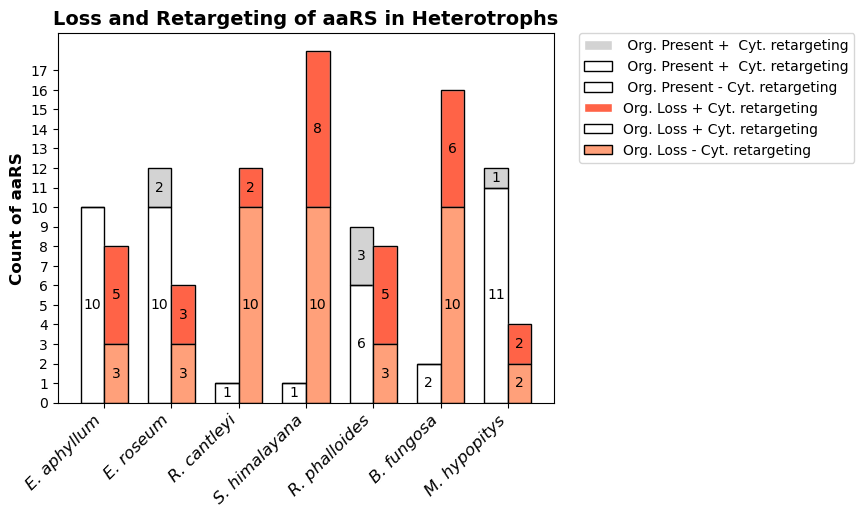

In [22]:
countstHolo=countst.loc['holoparasite']
labels=countstHolo.index.get_level_values(0).tolist()

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

toploss= countstHolo['loss_noretarget'] 
toppresent = countstHolo['present_noretarget'] 
fig, ax  = plt.subplots()

present1 = ax.bar(x - width/2,countstHolo['present_retarget'],width,edgecolor='white', color='lightgrey', label=' Org. Present +  Cyt. retargeting', bottom = toppresent)
present1 = ax.bar(x - width/2,countstHolo['present_retarget'],width,edgecolor='black', color='none', label=' Org. Present +  Cyt. retargeting', bottom = toppresent)
present2 = ax.bar(x - width/2, countstHolo['present_noretarget'],width,edgecolor='black', color='none',label=' Org. Present - Cyt. retargeting')


loss1 = ax.bar(x + width/2, countstHolo['loss_retarget'],width,edgecolor='white', color='tomato', label='Org. Loss + Cyt. retargeting',bottom = toploss)
loss1 = ax.bar(x + width/2, countstHolo['loss_retarget'],width,edgecolor='black', color='none', label='Org. Loss + Cyt. retargeting', bottom = toploss)
loss2 = ax.bar(x + width/2, countstHolo['loss_noretarget'],width,edgecolor='black', color='lightsalmon', label='Org. Loss - Cyt. retargeting') 


ax.set_ylabel('Count of aaRS',fontsize= 12, fontweight='bold')
ax.set_title('Loss and Retargeting of aaRS in Heterotrophs',fontsize= 14, fontweight='bold')




ax.bar_label(loss1,labels=countstHolo['loss_retarget'].astype(int).replace({0: " "}), padding=0, label_type='center')
ax.bar_label(loss2, padding=0,label_type='center')


ax.bar_label(present1,labels=countstHolo['present_retarget'].astype(int).replace({0: " "}), padding=0, label_type='center')
ax.bar_label(present2, padding=0,label_type='center')



plt.xticks(np.arange(min(x), max(x)+1, 1.0))
plt.yticks(np.arange(0, 18, 1.0))
ax.set_xticklabels(labels,fontsize= 12, rotation = 45, style= 'italic', ha='right')

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.show()

image_format = 'svg' # e.g .png, .svg, etc.
image_name = '20240821_absence_presence_retargeting.svg'

fig.savefig(image_name, format=image_format)